In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv(
    "eighteen_nineteen_university_datasets.csv", encoding="unicode_escape"
)

In [112]:
data

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Aga Khan University,Pakistan,3,-,> 1000,-,> 1000,> 1000,464,673,69.8
996,997,University of Calcutta,India,17,353,716,296,798,966,> 1000,> 1000,69.8
997,998,K?chi University,Japan,56,-,> 1000,-,> 1000,> 1000,811,673,69.8
998,999,Soonchunhyang University,South Korea,35,-,> 1000,-,881,> 1000,> 1000,898,69.8


In [113]:
df = pd.DataFrame(data=data)

In [114]:
row, col = df.shape
print(f"row: {row}")
print(f"columns: {col}")

row: 1000
columns: 12


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   object 
 5   Alumni Employment     1000 non-null   object 
 6   Quality of Faculty    1000 non-null   object 
 7   Research Output       1000 non-null   object 
 8   Quality Publications  1000 non-null   object 
 9   Influence             1000 non-null   object 
 10  Citations             1000 non-null   object 
 11  Score                 1000 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 93.9+ KB


In [116]:
df.describe(include="all")

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
count,1000.000000,1000,1000,1000.00000,1000,1000,1000,1000,1000,1000,1000,1000.000000
unique,NaN,1000,61,NaN,404,492,221,905,892,830,75,NaN
top,NaN,Capital Normal University,USA,NaN,-,> 1000,-,> 1000,> 1000,> 1000,898,NaN
freq,NaN,1,213,NaN,597,509,731,77,51,171,129,NaN
mean,500.500000,NaN,NaN,40.02300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.034300
std,288.819436,NaN,NaN,49.22871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.670858
min,1.000000,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.800000
25%,250.750000,NaN,NaN,6.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.500000
50%,500.500000,NaN,NaN,21.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.750000
75%,750.250000,NaN,NaN,51.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.300000


In [117]:
for col in df.columns:
    print(f"unique values in {col}")
    print(f"{df[col].unique()}")
    print("_" * 80)

unique values in World Rank
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  19

There are many incorrect values, including:<br>
"-","> 1000",

## Data cleaning

In [118]:
max = 1000
df.replace(["-", "> 1000"], value=max + 1, inplace=True)

In [119]:
df["Quality\xa0of Education"]=df["Quality\xa0of Education"].astype(np.int16)
df["Alumni Employment"] = df["Alumni Employment"].astype(np.int16)
df["Quality\xa0of Faculty"] = df["Quality\xa0of Faculty"].astype(np.int16)
df["Research Output"] = df["Research Output"].astype(np.int16)
df["Quality Publications"] = df["Quality Publications"].astype(np.int16)
df["Influence"] = df["Influence"].astype(np.int16)
df["Citations"] = df["Citations"].astype(np.int16)
df["Score"] = df["Score"].astype(np.float16)

# Let's move on to data visualization

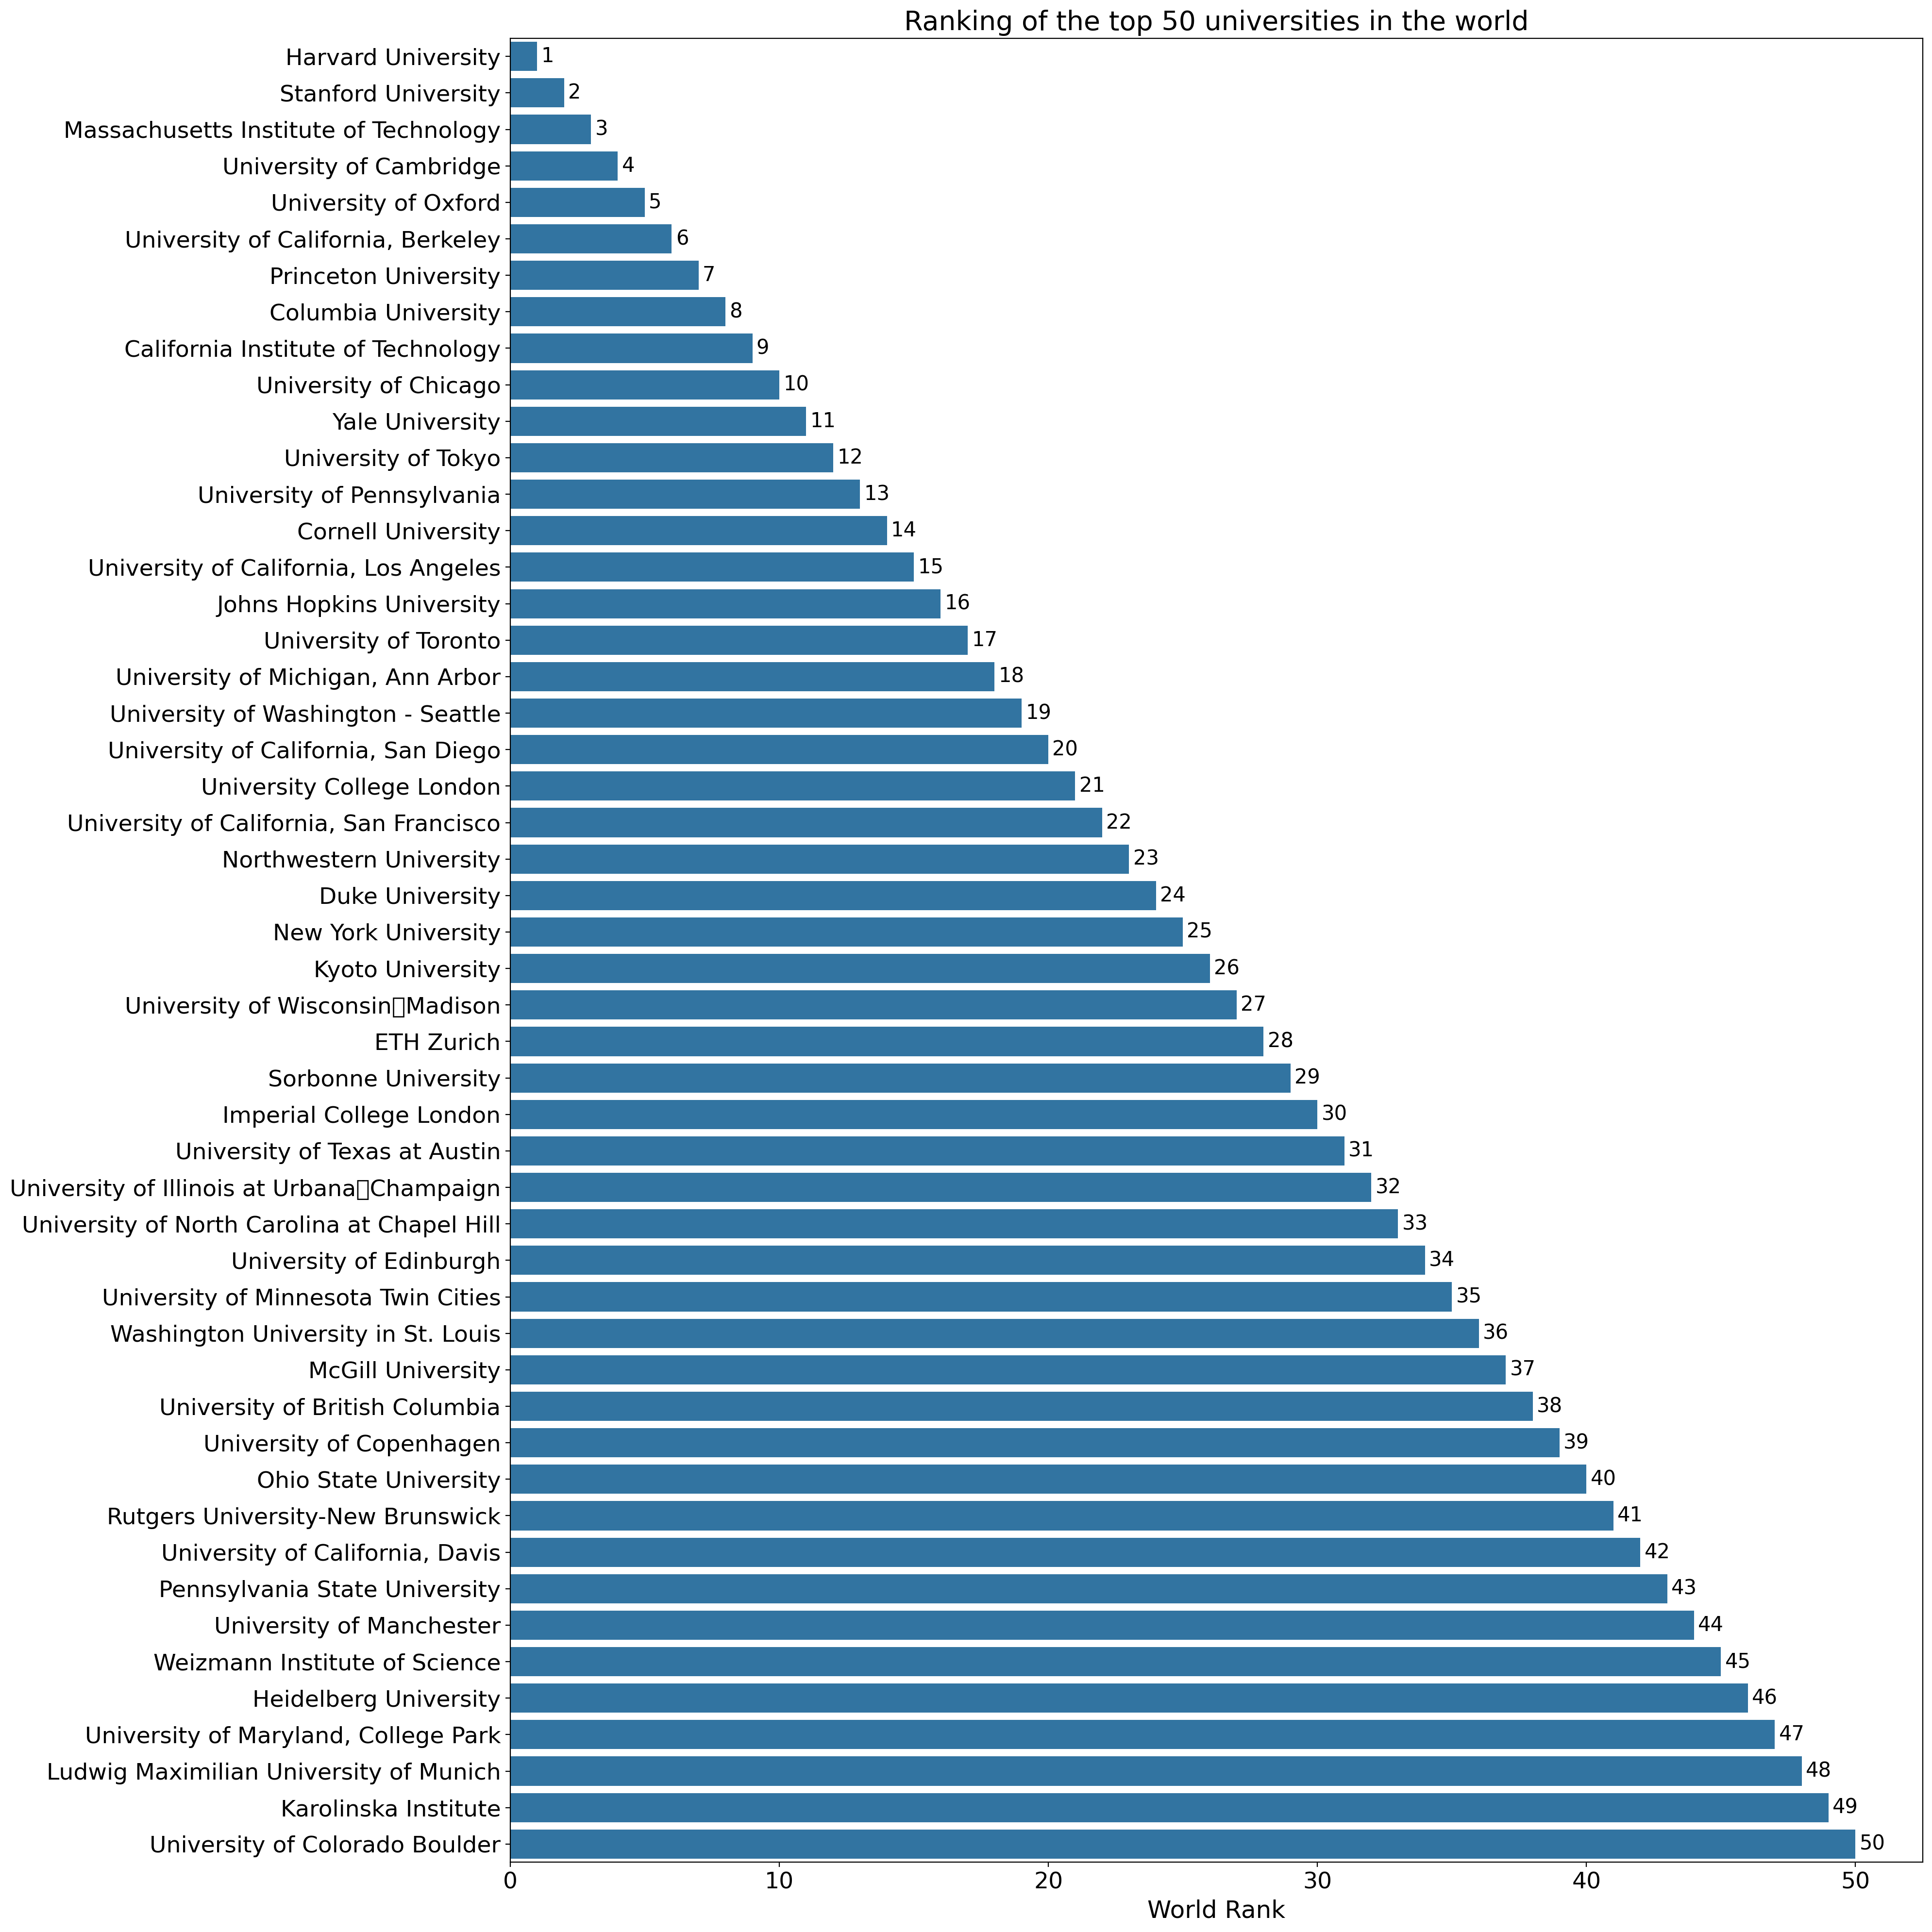

In [120]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(data=df[df["World Rank"] <= 50], x="World Rank", y="Institution")
plt.title("Ranking of the top 50 universities in the world", fontsize=20)
plt.xlabel("World Rank", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

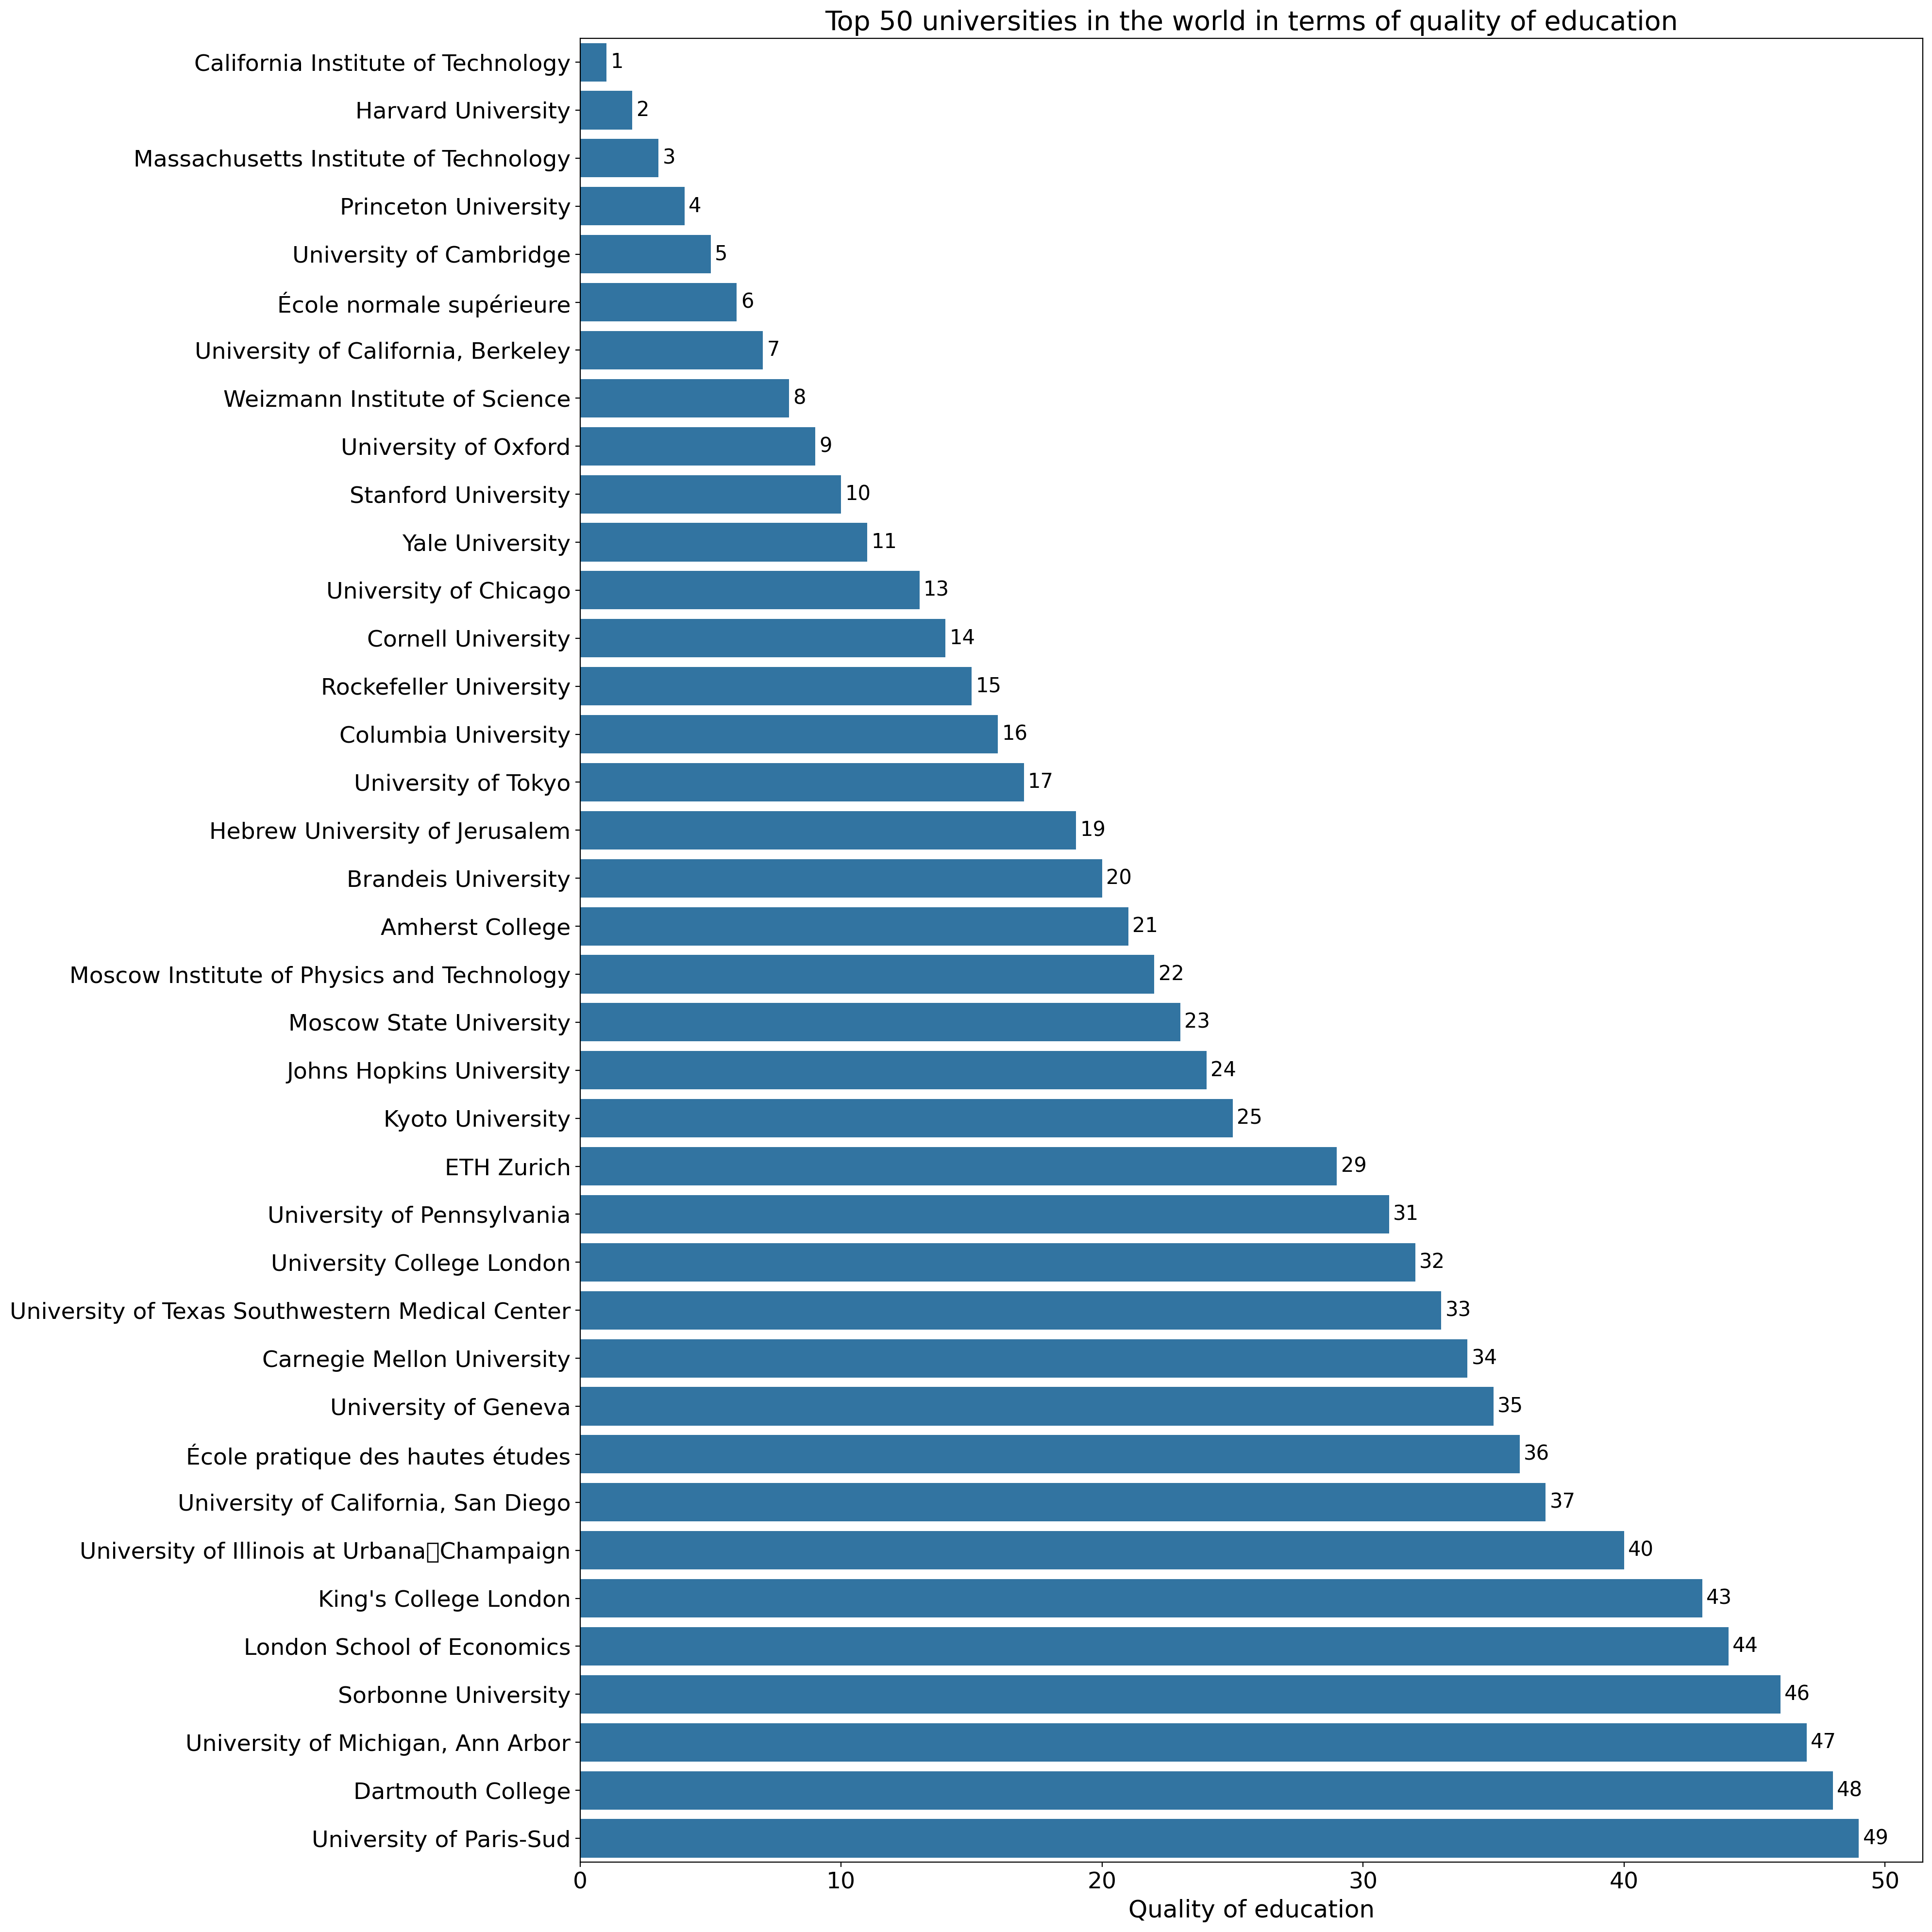

In [121]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Quality\xa0of Education"] <= 50].sort_values(
        by="Quality\xa0of Education"
    ),
    x="Quality\xa0of Education",
    y="Institution",
)
plt.title(
    "Top 50 universities in the world in terms of quality of education", fontsize=20
)
plt.xlabel("Quality of education", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

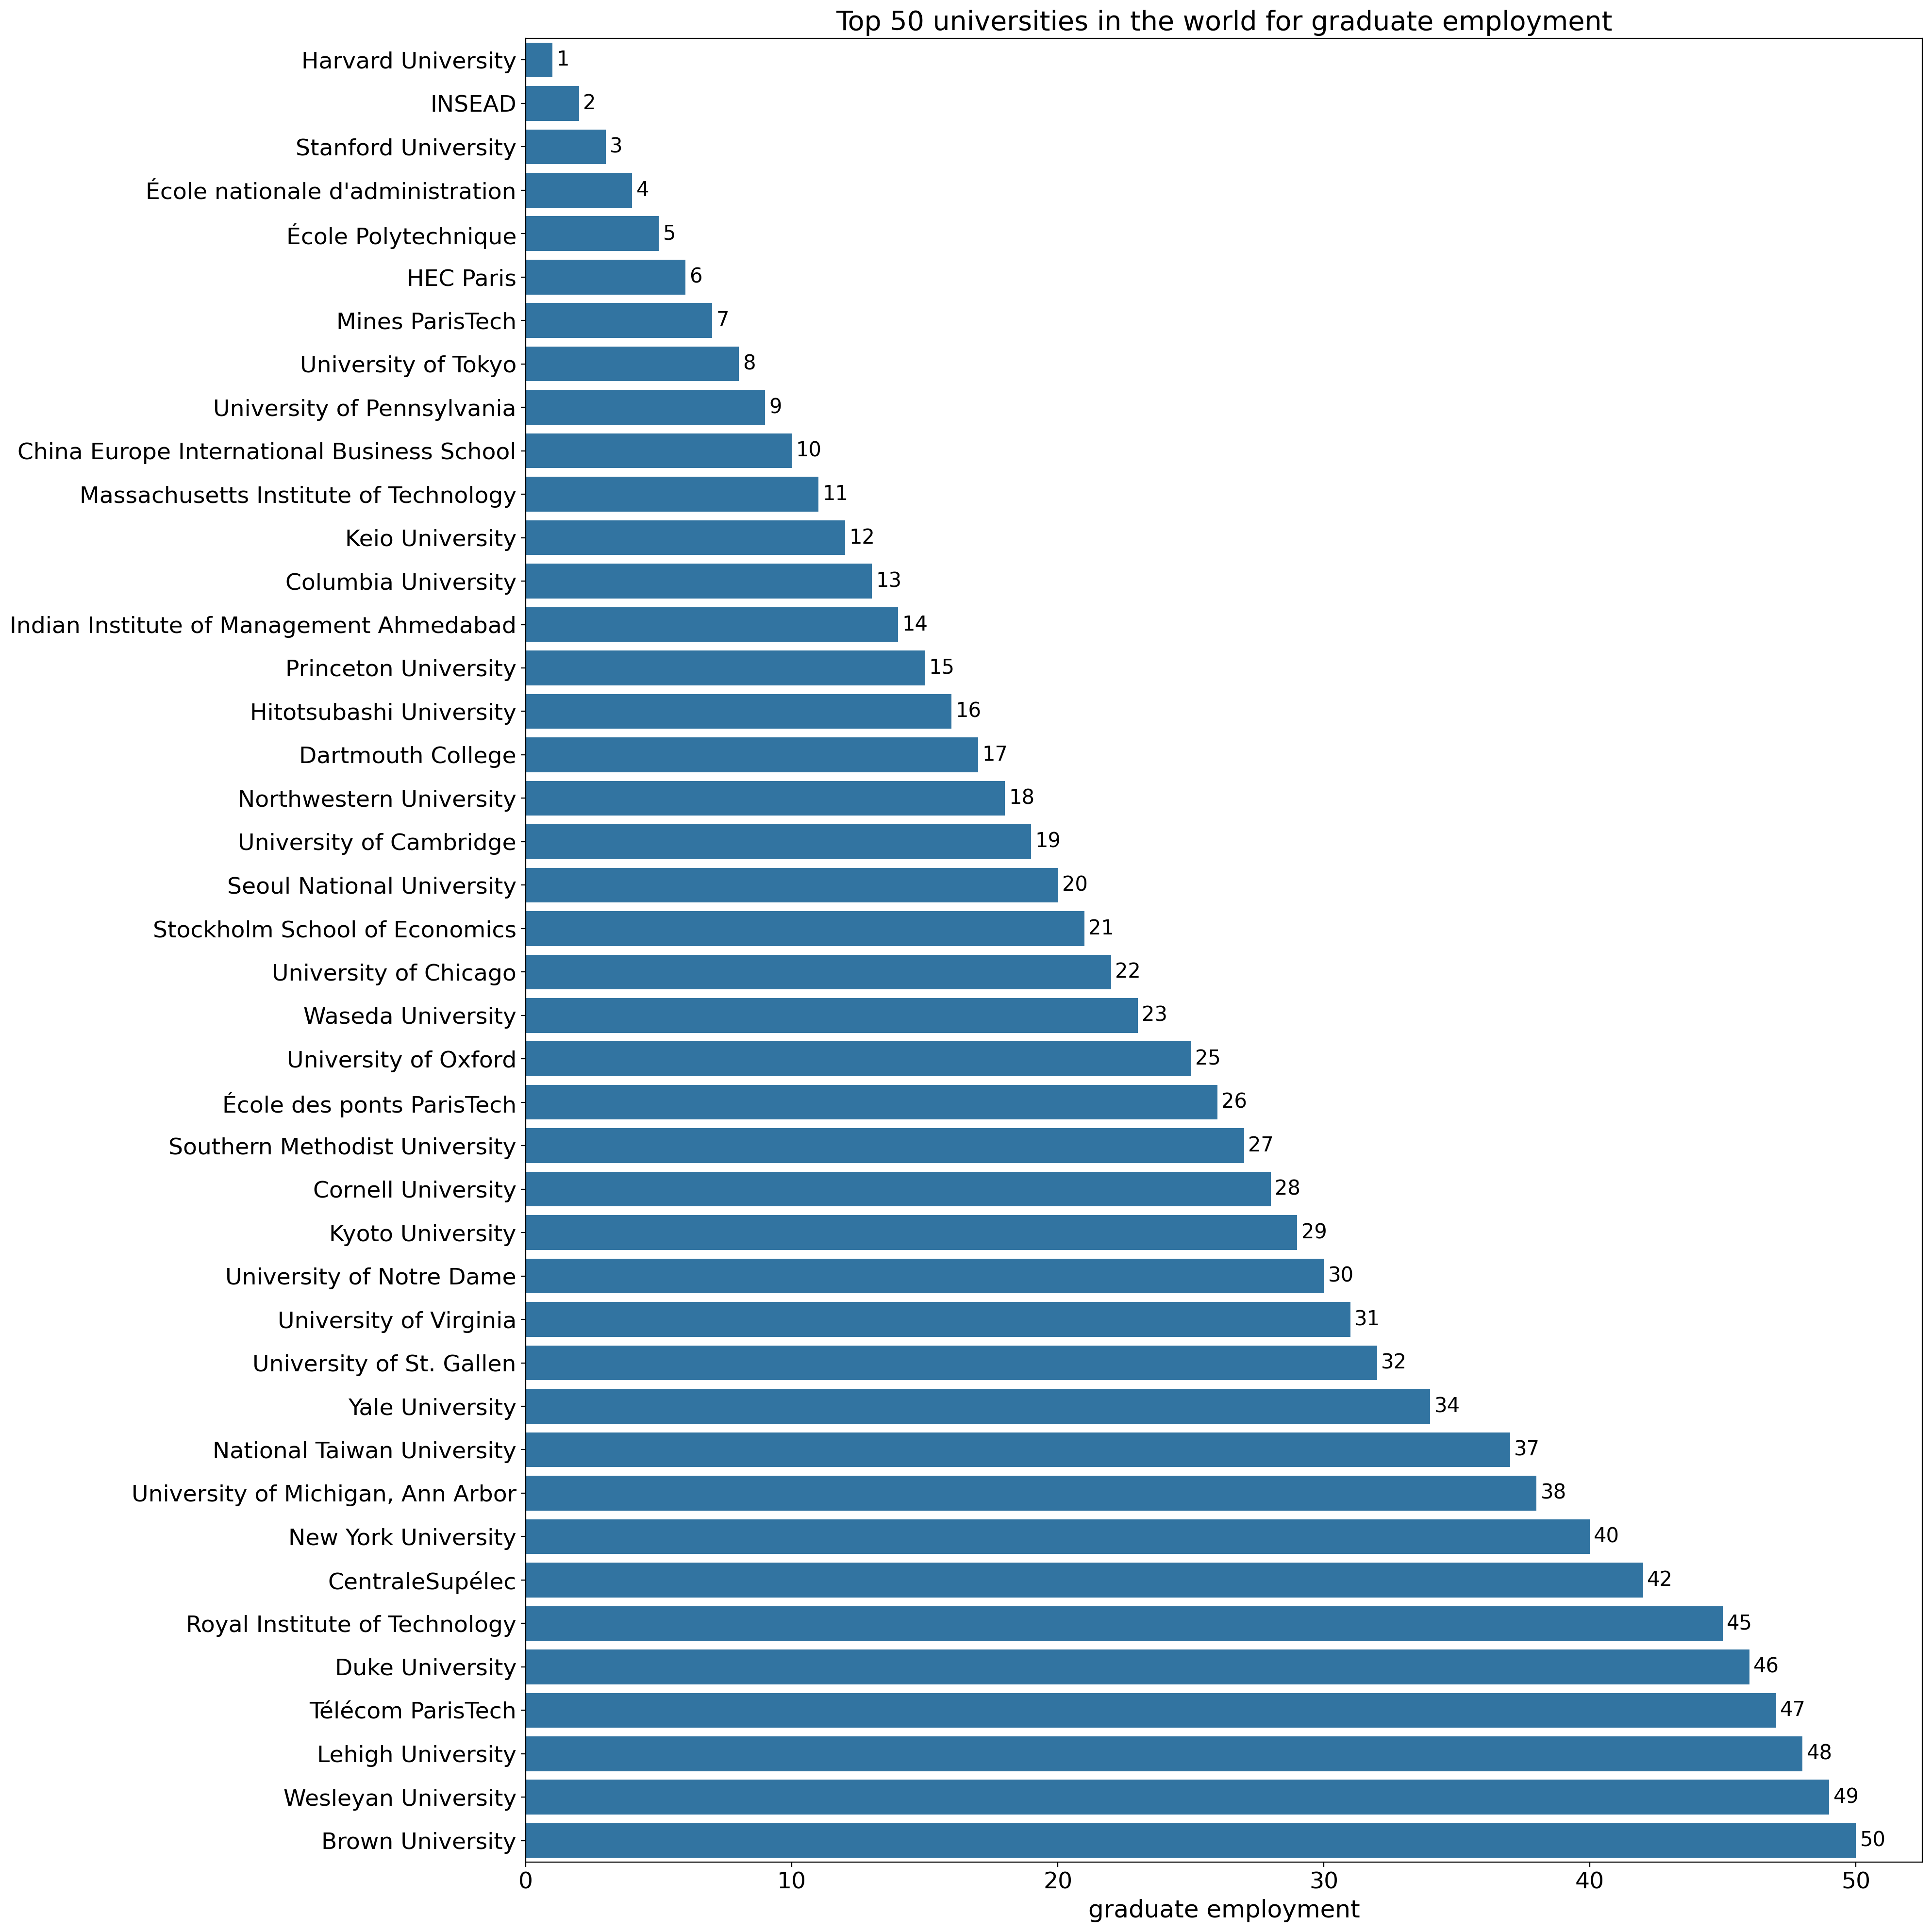

In [122]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Alumni Employment"] <= 50].sort_values(by="Alumni Employment"),
    x="Alumni Employment",
    y="Institution",
)
plt.title("Top 50 universities in the world for graduate employment", fontsize=20)
plt.xlabel("graduate employment", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

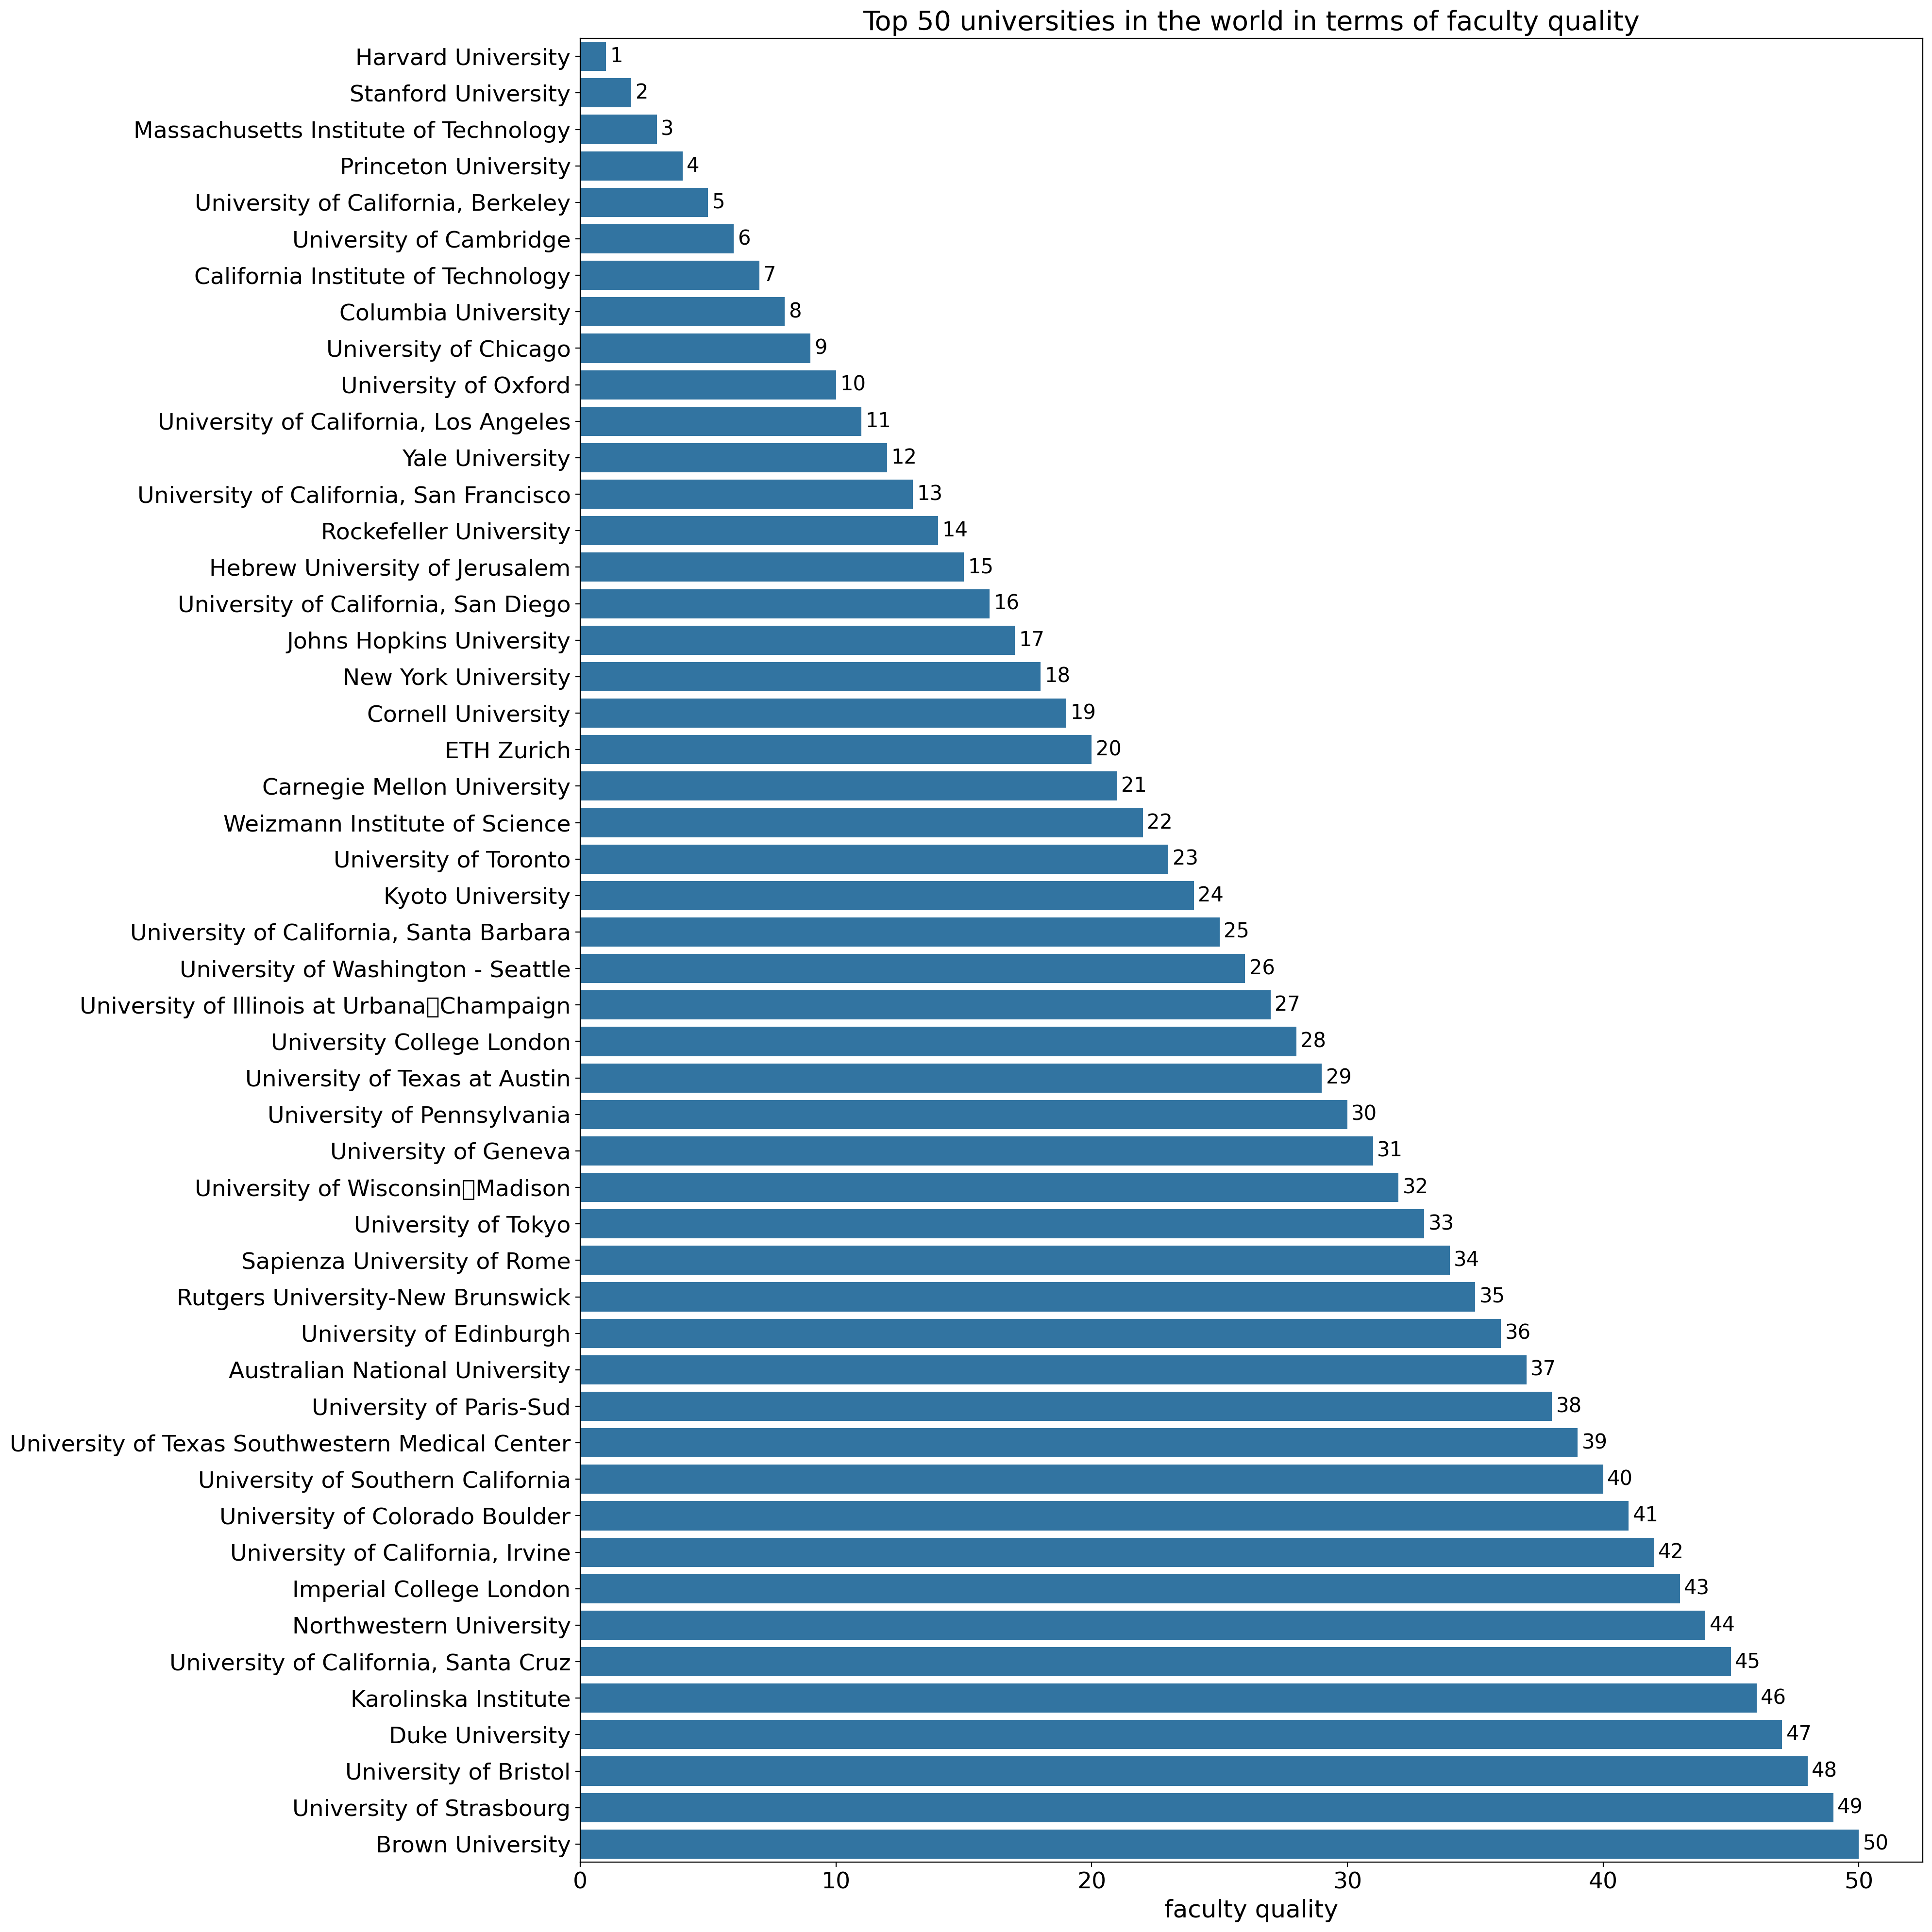

In [123]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Quality\xa0of Faculty"] <= 50].sort_values(by="Quality\xa0of Faculty"),
    x="Quality\xa0of Faculty",
    y="Institution",
)
plt.title("Top 50 universities in the world in terms of faculty quality", fontsize=20)
plt.xlabel("faculty quality", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

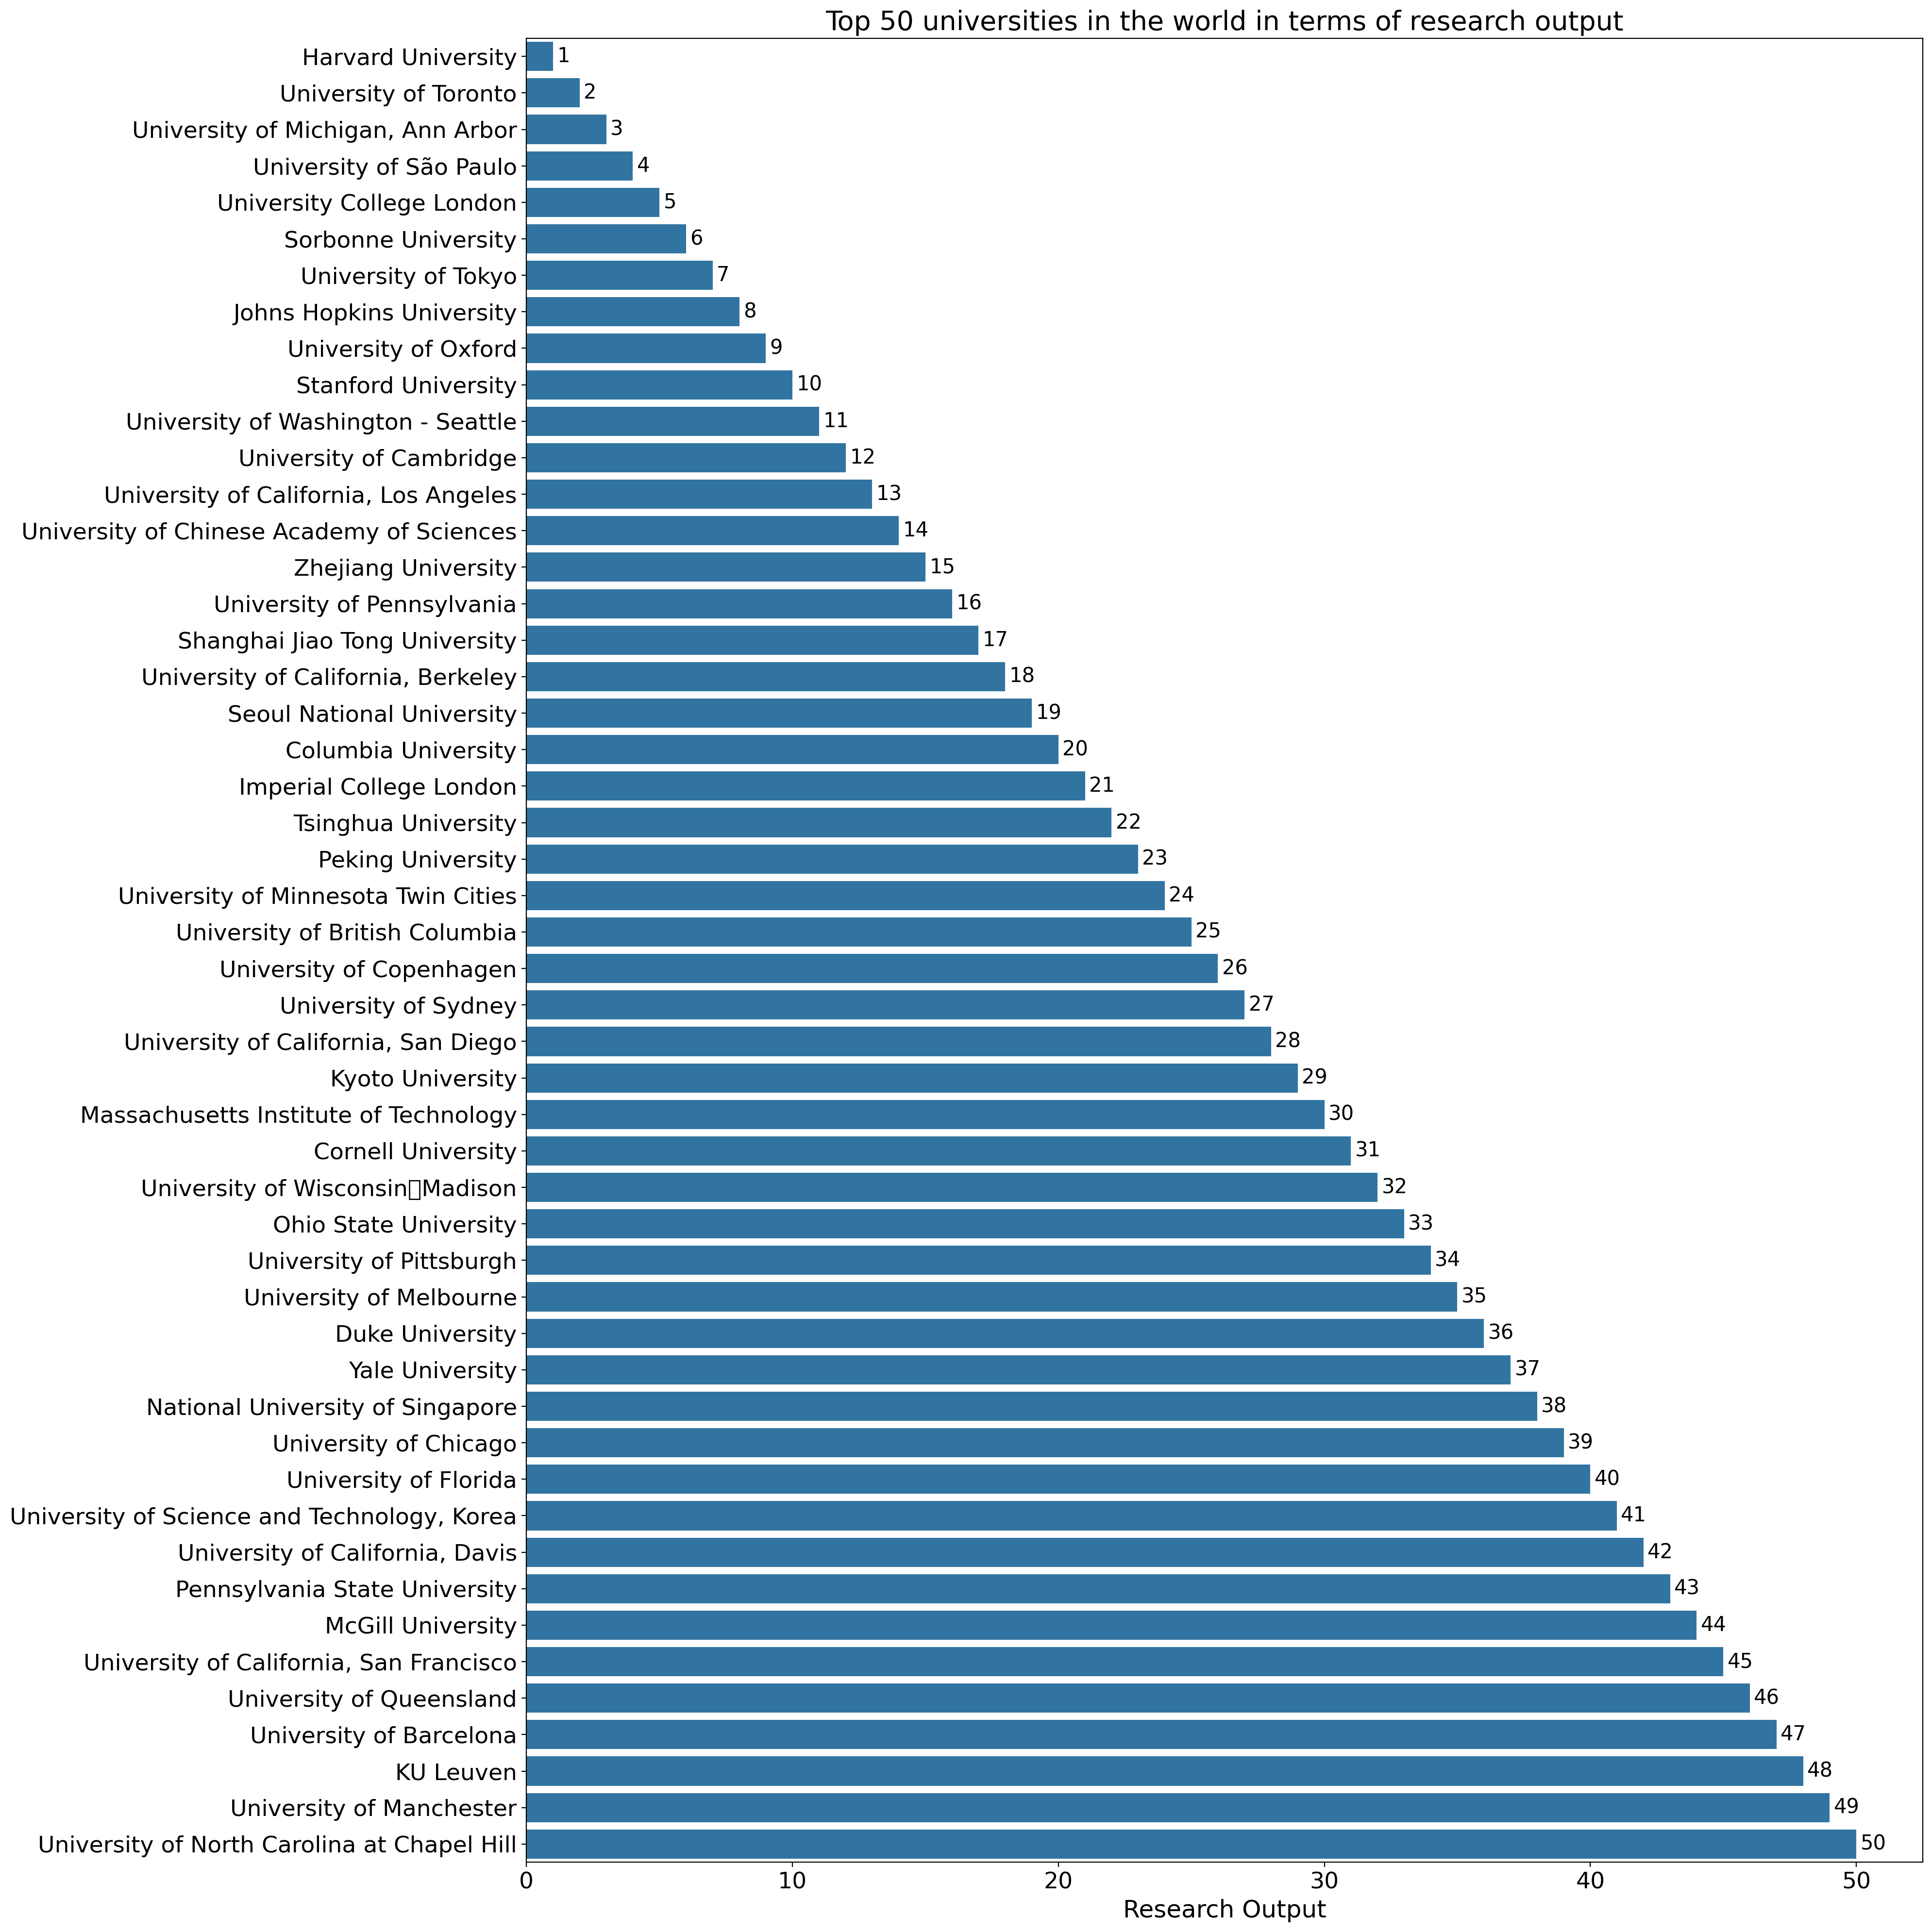

In [124]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Research Output"] <= 50].sort_values(by="Research Output"),
    x="Research Output",
    y="Institution",
)
plt.title("Top 50 universities in the world in terms of research output", fontsize=20)
plt.xlabel("Research Output", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

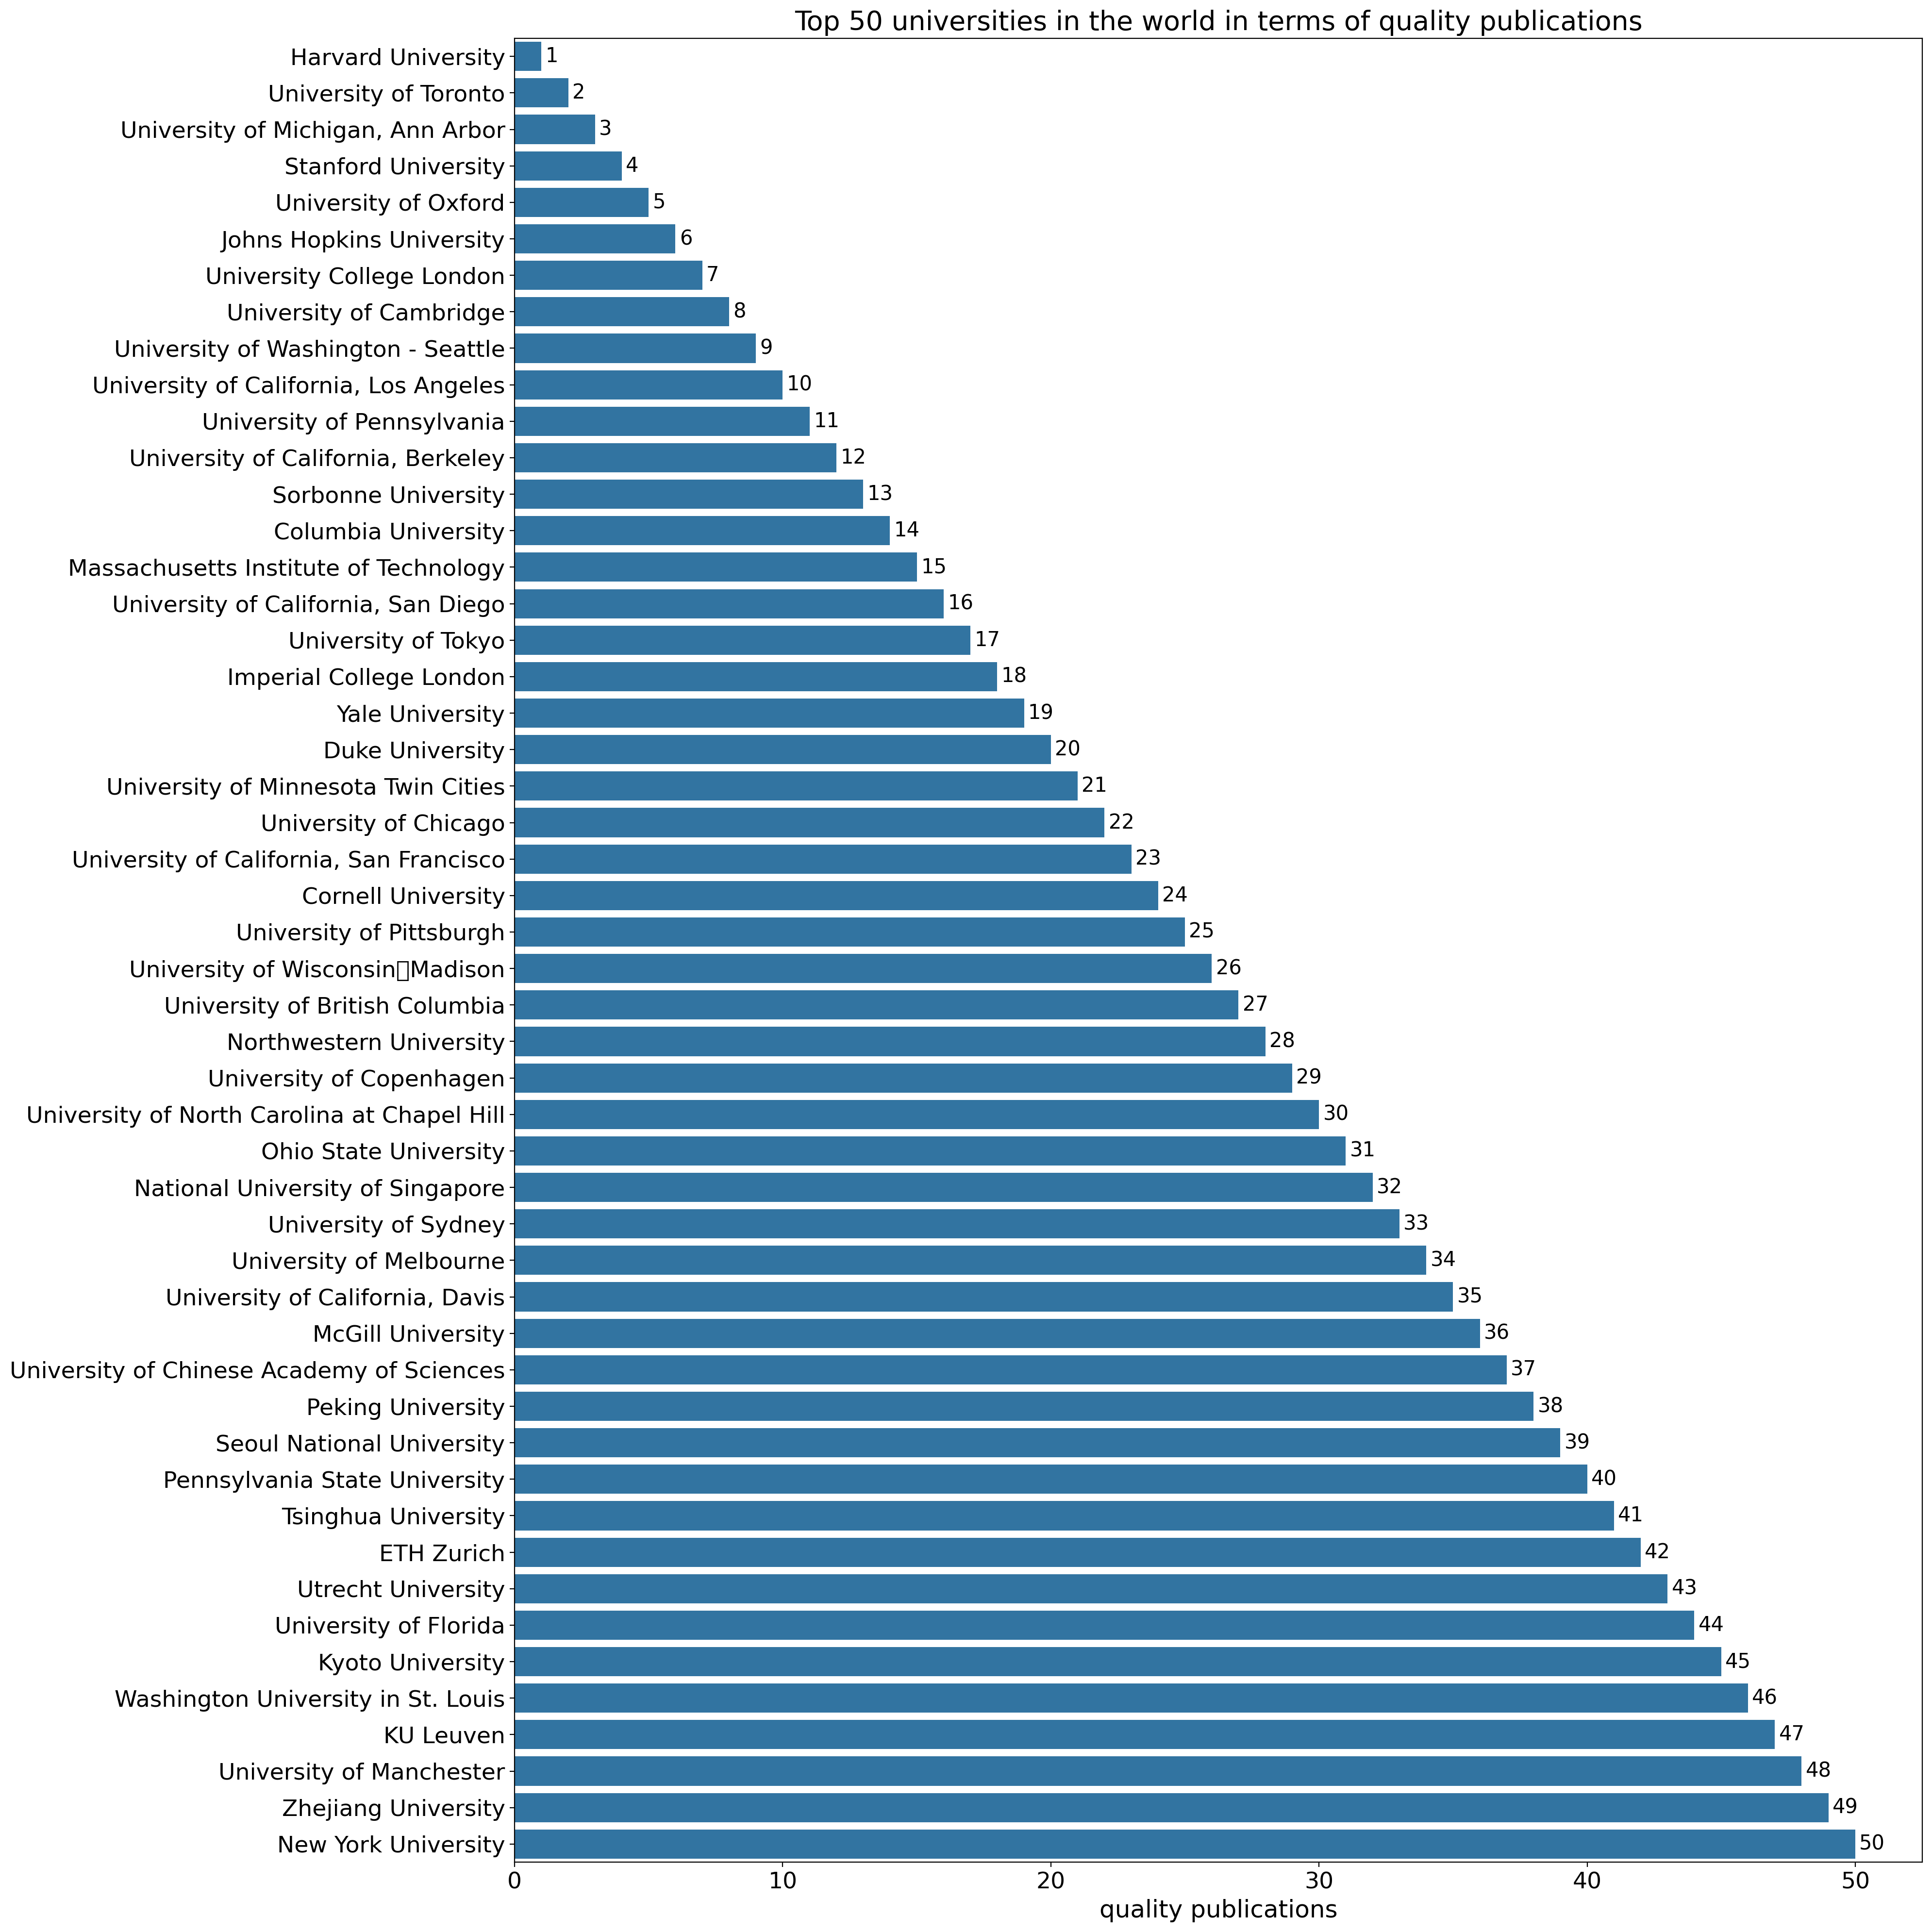

In [125]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Quality Publications"] <= 50].sort_values(by="Quality Publications"),
    x="Quality Publications",
    y="Institution",
)
plt.title(
    "Top 50 universities in the world in terms of quality publications", fontsize=20
)
plt.xlabel("quality publications", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

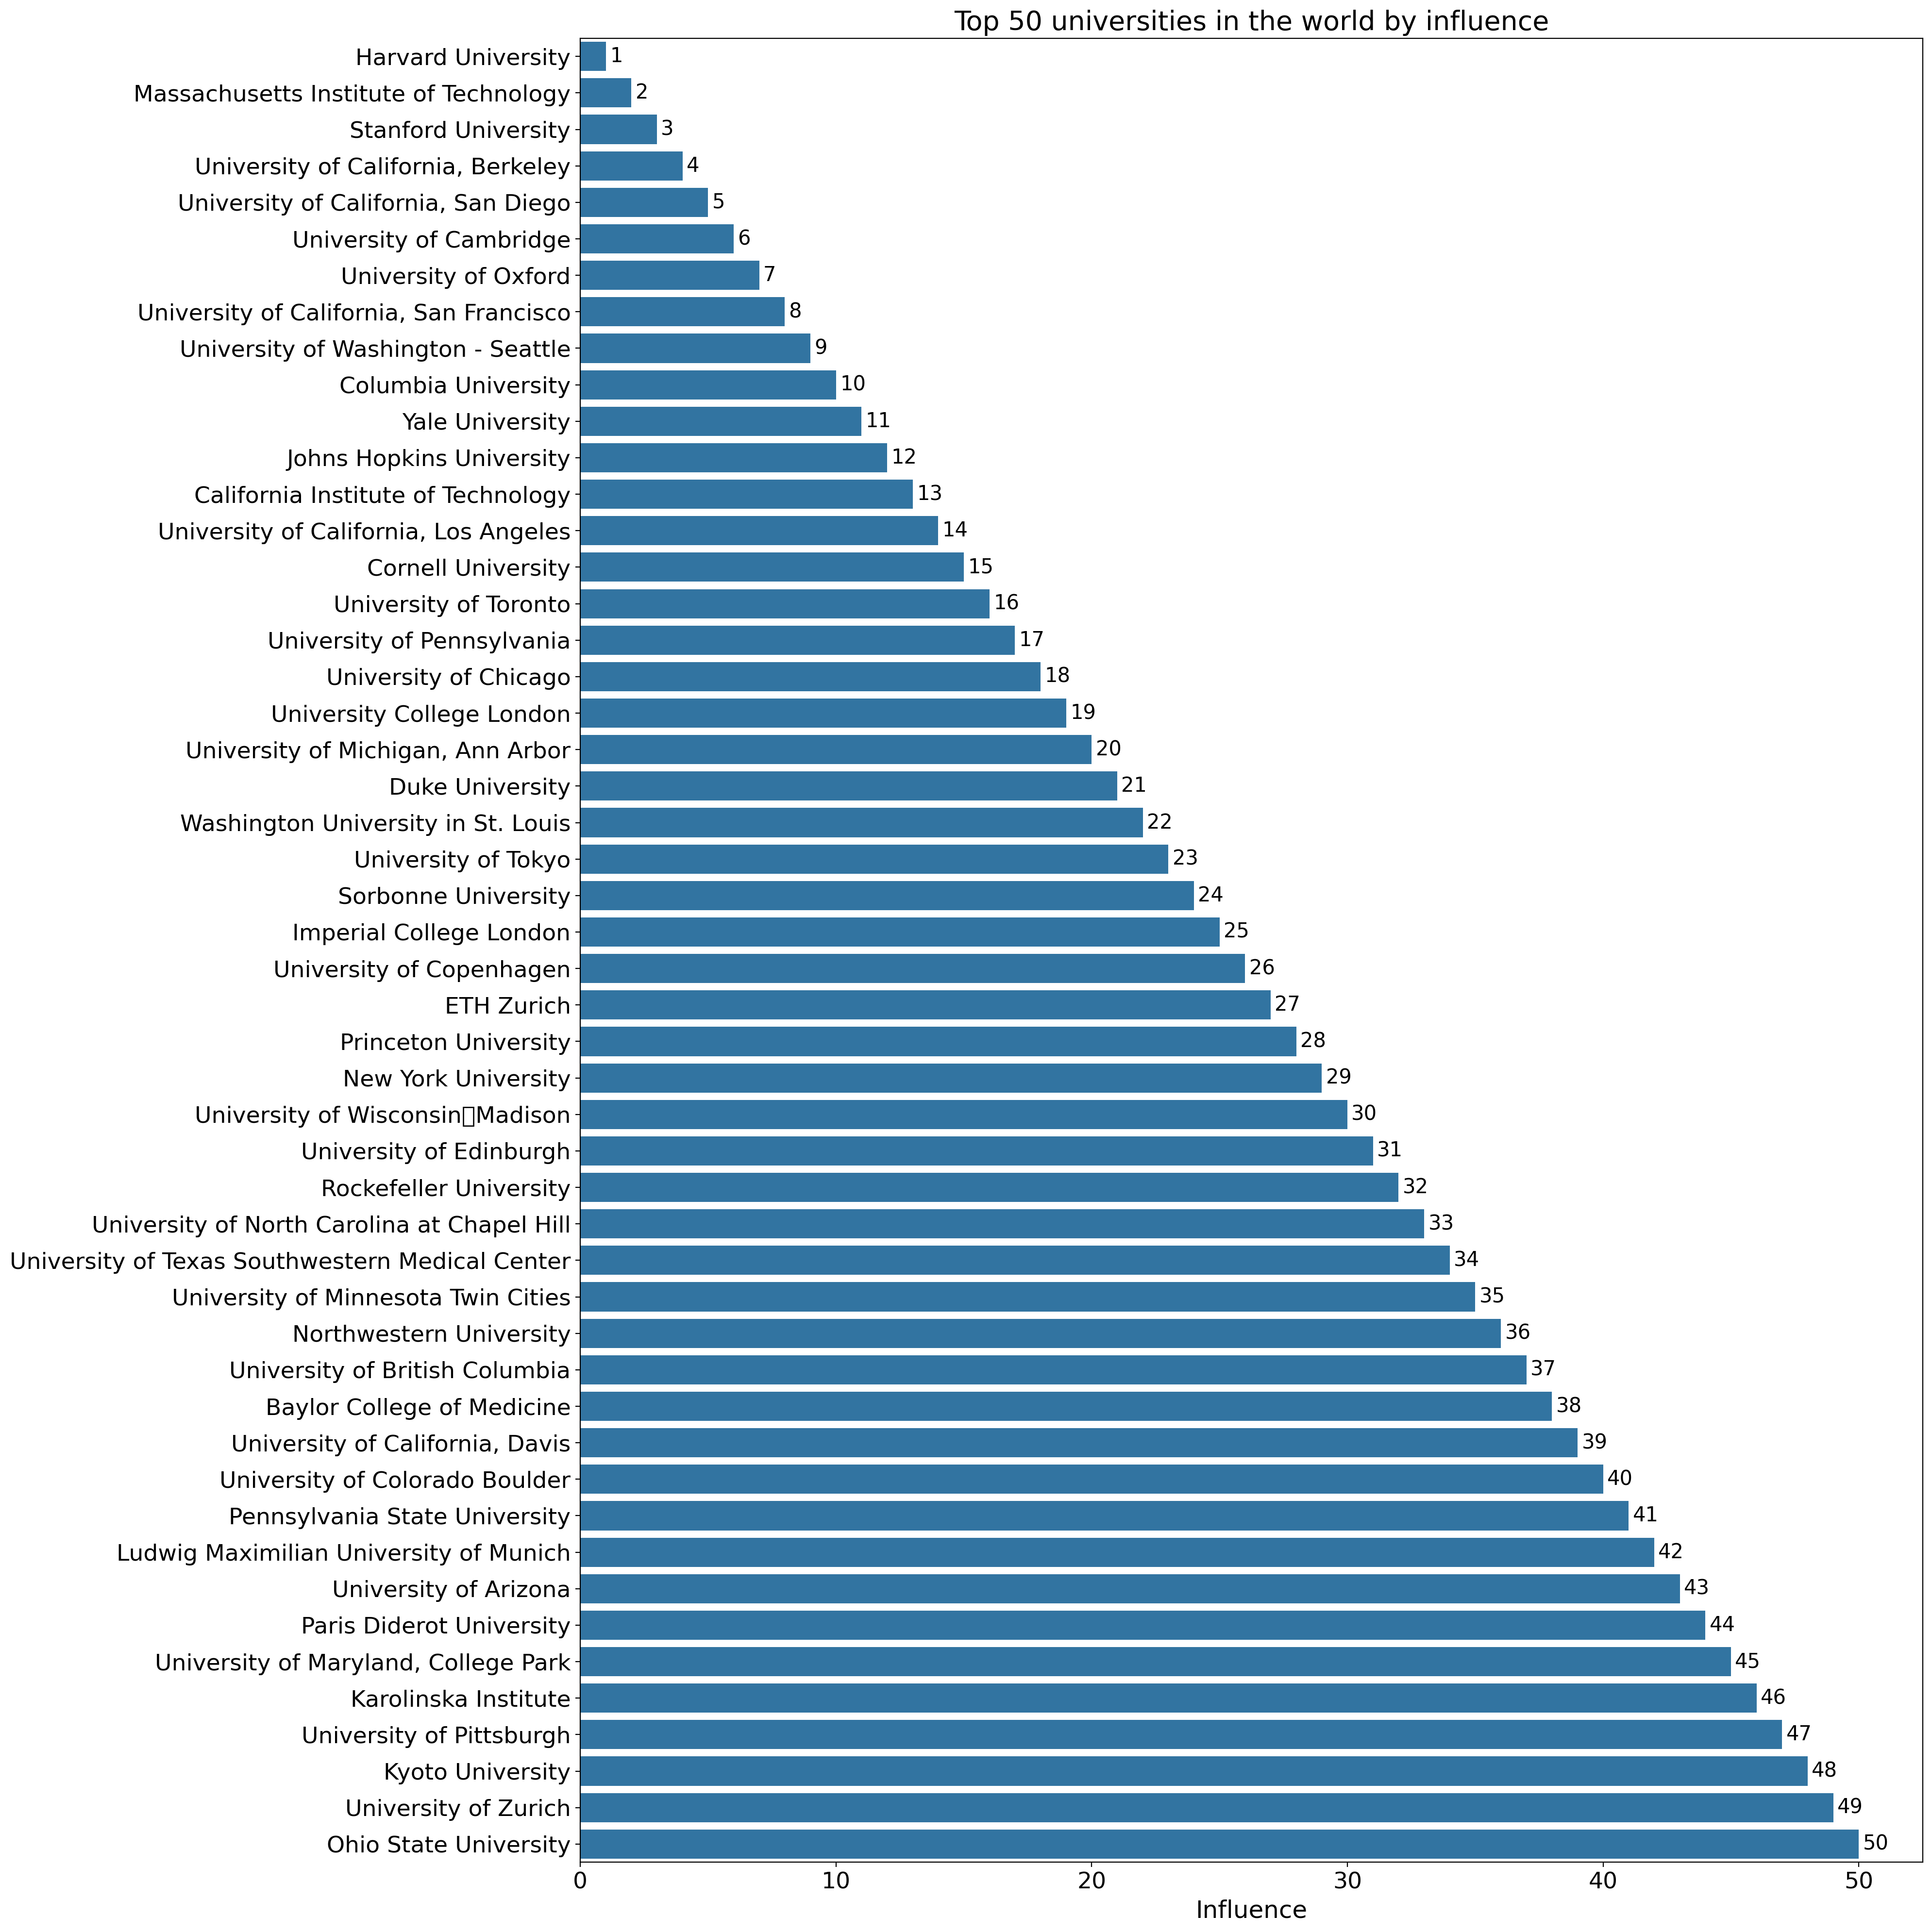

In [126]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Influence"] <= 50].sort_values(by="Influence"),
    x="Influence",
    y="Institution",
)
plt.title("Top 50 universities in the world by influence", fontsize=20)
plt.xlabel("Influence", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

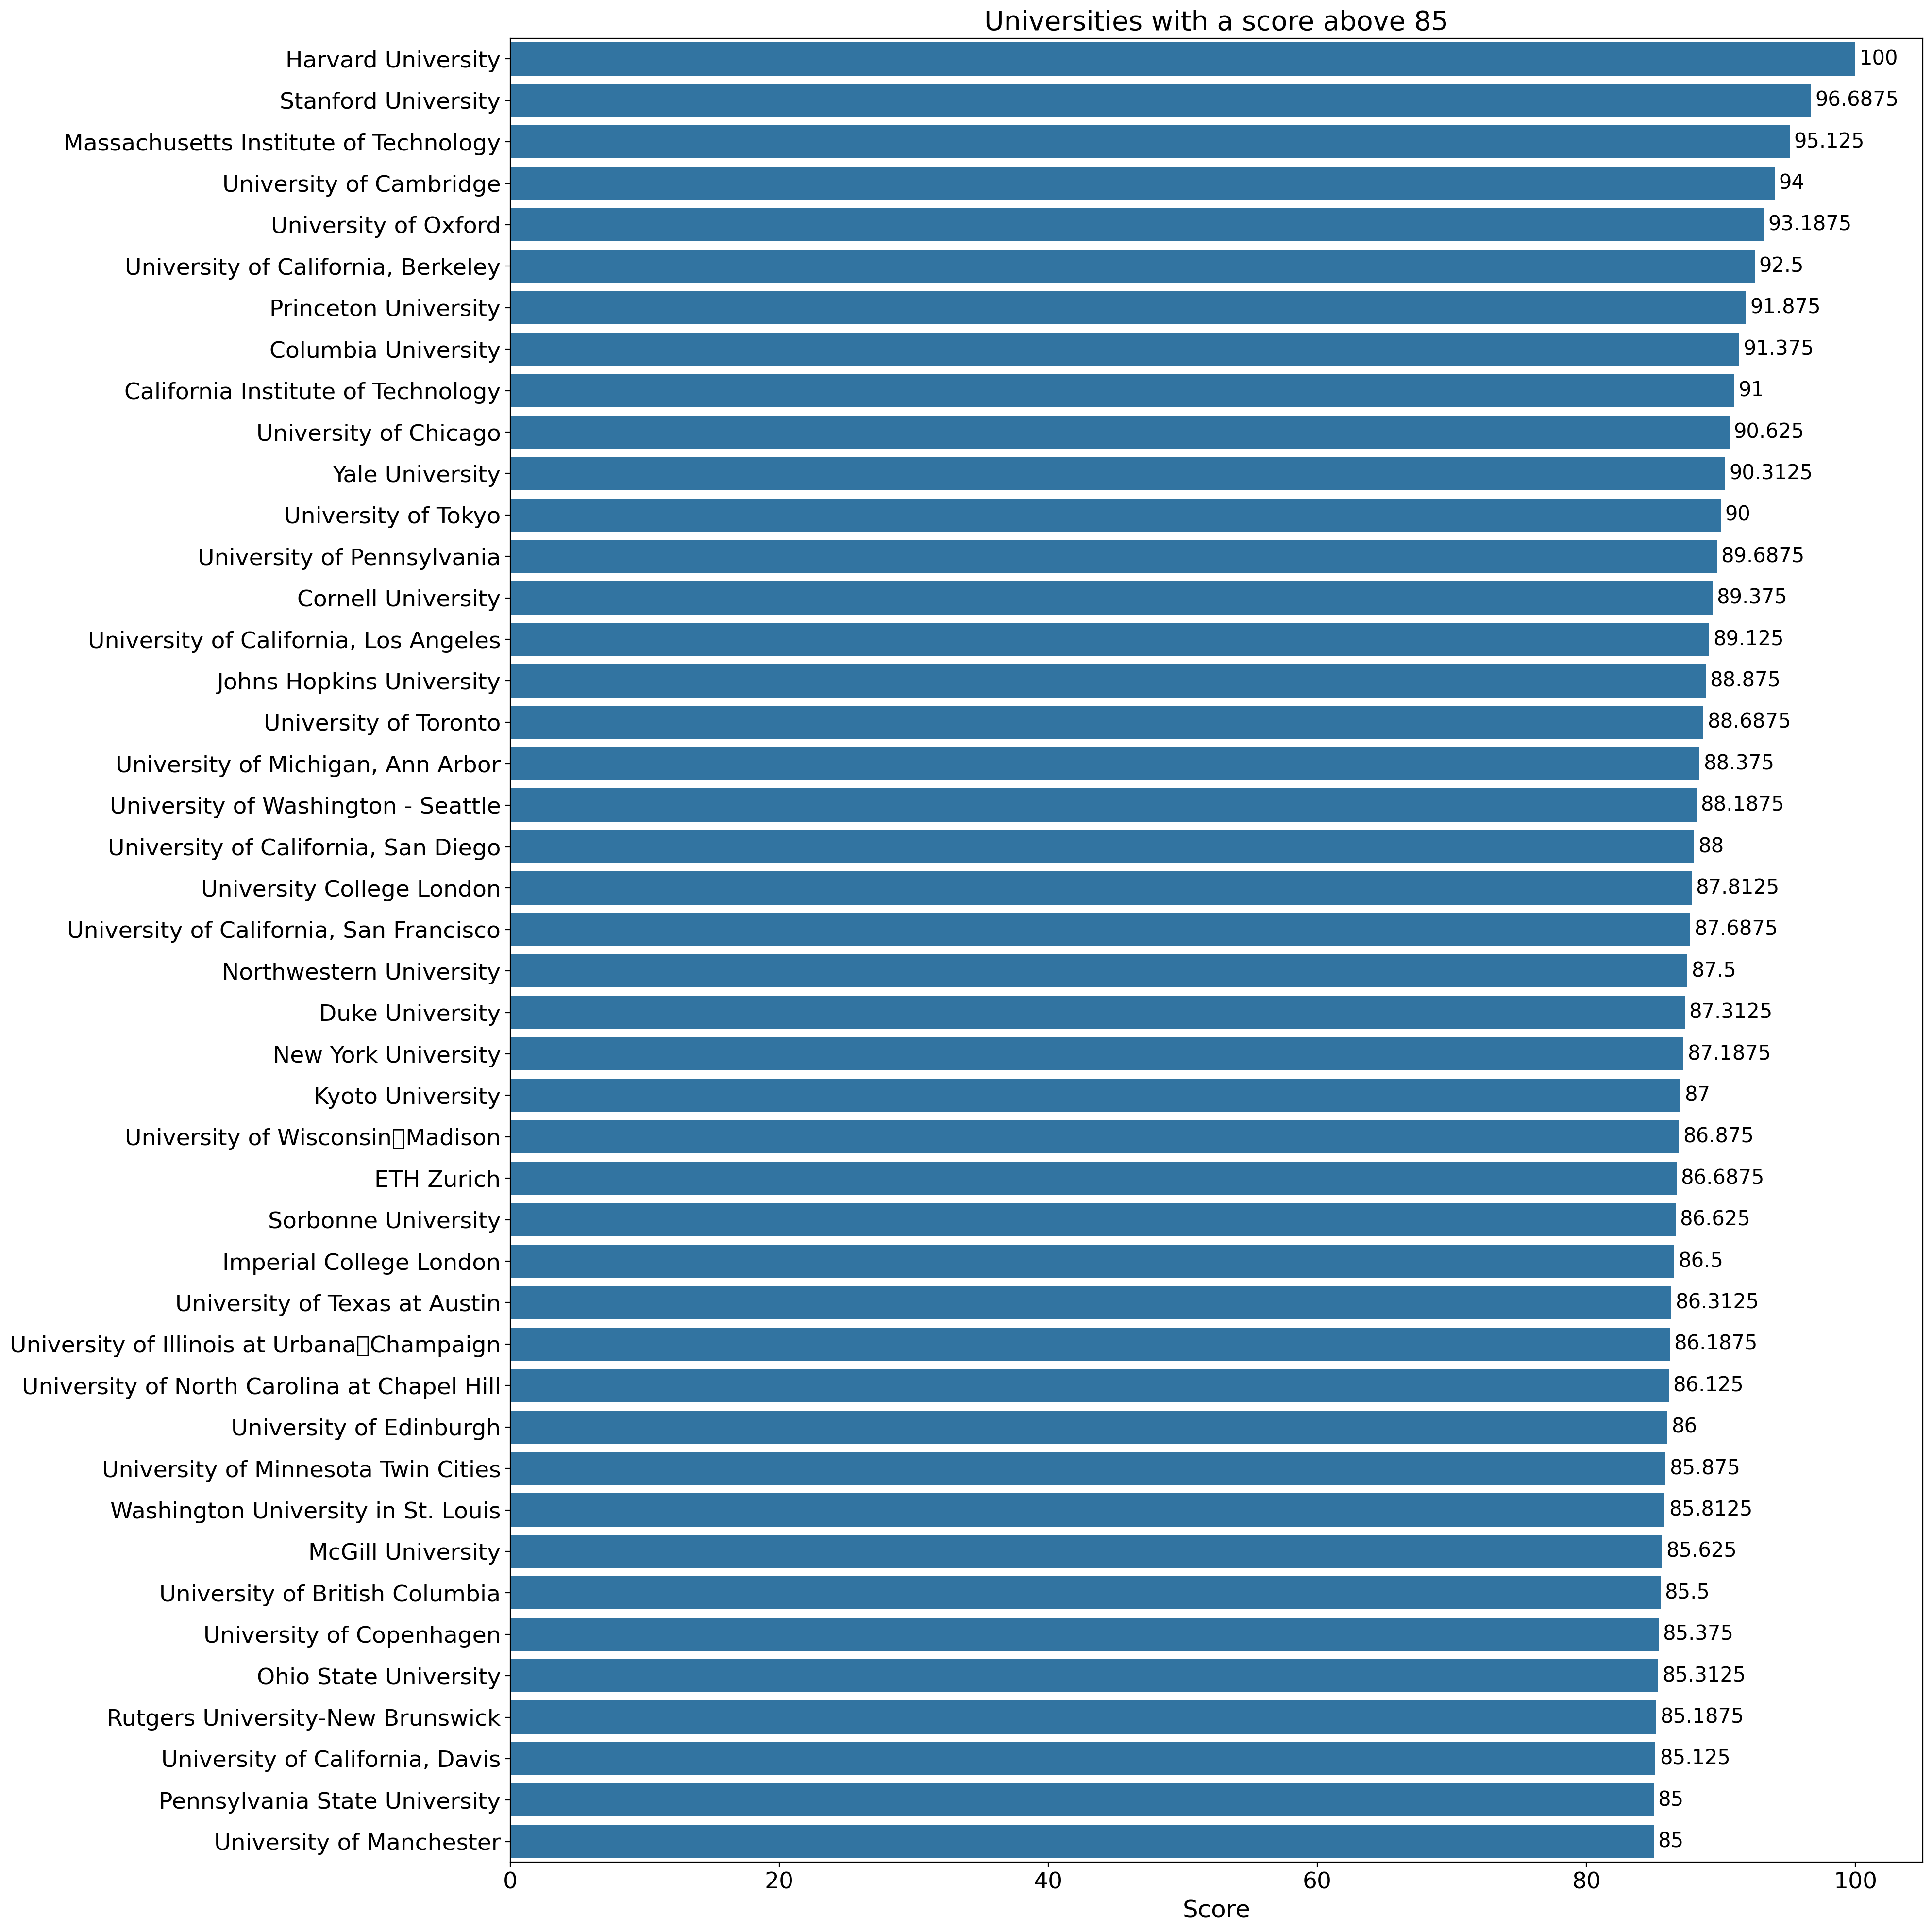

In [127]:
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(
    data=df[df["Score"] >= 85].sort_values(by="Score", ascending=False),
    x="Score",
    y="Institution",
)
plt.title("Universities with a score above 85", fontsize=20)
plt.xlabel("Score", fontsize=18)
plt.ylabel("")
plt.tick_params(axis="both", labelsize=17)
ax.bar_label(ax.containers[0], padding=3, fontsize=15)
plt.tight_layout()
plt.show()

In [128]:
country_rank = df.groupby("Location")["Score"].mean().reset_index()
fig = px.choropleth(
    country_rank,
    locations="Location",
    locationmode="country names",
    color="Score",
    title="Average University Score by Country",
    hover_name="Location",
)
fig.update_layout(title_x=0.5)
fig.show()

In [129]:
fig = px.scatter(df, x="Quality\xa0of Education", y="Research Output",
                 size="Score", color="Location", hover_name="Institution",
                 title="Education Quality vs Research Output")
fig.update_layout(title_x=0.5)
fig.show()


In [130]:
best_rank = df.groupby("Location")["World Rank"].min().reset_index()

fig = px.choropleth(best_rank, locations="Location",
                    locationmode="country names",
                    color="World Rank",
                    hover_name="Location", 
                    title="Best University Rank by Country (Lower = Better)")
fig.update_layout(title_x=0.5, coloraxis_colorbar_title="Best Rank")
fig.show()
